## 📂 FMCG Company — Customer & Sales Analysis
---
We are given customer data from an FMCG (Fast Moving Consumer Goods) company. The data has information about customer background, income and how much each customer has spent on different product categories like Wine, Fruits, Meat, Fish, Sweets and Gold products.

Our job as a Data Analyst is to explore this data, clean it, and find out patterns like which product category earns the most, who the main customers are, and whether income affects spending.

---

#### **Step 1:-** 🗂️ Import Necessary Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

We are reading the dataset. This dataset is separated by semicolon ( ; ) instead of comma, so we mention that while reading.

In [2]:
df = pd.read_csv('marketing_campaign.csv', sep=';')
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0


#### **Step 2:-** 😃 Get Dimension and Missing value count per column

In [3]:
dim = df.shape
print(f"This dataset has {dim[0]} rows and {dim[1]} columns")

This dataset has 2240 rows and 29 columns


In [4]:
df.isna().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

There are 24 missing values in the Income column. Since we have 2240 rows in total, dropping 24 rows will not affect our analysis much. So we will drop those rows.

In [5]:
df = df.dropna(subset=["Income"]).reset_index(drop=True)

#### **Step 3:-** 🧹 Check and clean incorrect entries

In [6]:
df["Income"].describe()

count      2216.000000
mean      52247.251354
std       25173.076661
min        1730.000000
25%       35303.000000
50%       51381.500000
75%       68522.000000
max      666666.000000
Name: Income, dtype: float64

The maximum income value is 666666 which is way higher than the 75th percentile (~68522). This looks like a wrong entry / outlier, not a real customer income. So we remove rows where Income is unusually high (above 200000).

In [7]:
df = df[df["Income"] < 200000].reset_index(drop=True)

In [8]:
df["Marital_Status"].value_counts()

Marital_Status
Married     857
Together    572
Single      471
Divorced    232
Widow        76
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

We can see categories like `Alone`, `Absurd` and `YOLO` which are not real marital status values, they are junk entries with very few rows. We will remove those rows.

In [9]:
junk = ["Alone", "Absurd", "YOLO"]
df = df[~df["Marital_Status"].isin(junk)].reset_index(drop=True)
df["Marital_Status"].value_counts()

Marital_Status
Married     857
Together    572
Single      471
Divorced    232
Widow        76
Name: count, dtype: int64

#### **Step 4:-** ✅ Create a Total Spend column

The dataset has separate spend columns for each product category (Wine, Fruits, Meat, Fish, Sweets, Gold). We add them up to get a Total Spend for each customer, which we will use later.

In [10]:
df["Total_Spend"] = (df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] +
                      df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"])
df[["MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds", "Total_Spend"]].head()

,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,Total_Spend
0,635,88,546,172,88,88,1617
1,11,1,6,2,1,6,27
2,426,49,127,111,21,42,776
3,11,4,20,10,3,5,53
4,173,43,118,46,27,15,422


---
### 📊 Graph 1 — Total Spending by Product Category (Bar Diagram)
---
**❓ Question we are trying to answer:**
*Which product category brings in the most revenue for this FMCG company?*

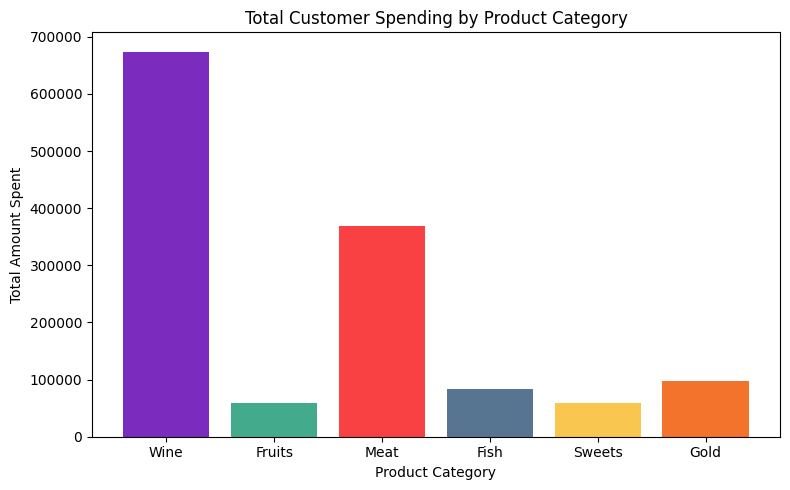

In [11]:
category_spend = {
    "Wine": df["MntWines"].sum(),
    "Fruits": df["MntFruits"].sum(),
    "Meat": df["MntMeatProducts"].sum(),
    "Fish": df["MntFishProducts"].sum(),
    "Sweets": df["MntSweetProducts"].sum(),
    "Gold": df["MntGoldProds"].sum()
}

categories = list(category_spend.keys())
totals = list(category_spend.values())

plt.figure(figsize=(8, 5))
plt.bar(categories, totals, color=["#7B2CBF", "#43AA8B", "#F94144", "#577590", "#F9C74F", "#F3722C"])
plt.xlabel("Product Category")
plt.ylabel("Total Amount Spent")
plt.title("Total Customer Spending by Product Category")
plt.tight_layout()
plt.show()

**✅ Answer :-**
* **Wine** and **Meat** are by far the highest earning categories for this FMCG company, together making up more than half of the total spend.
* **Fruits**, **Fish**, **Sweets** and **Gold** products are bought in much smaller amounts compared to Wine and Meat.
* So, the answer to our question is clear — **Wine and Meat are the top revenue-generating categories.**

**Interpretation :-**
* This tells the company that Wine and Meat are their core revenue drivers, so stock, offers and marketing budget should be prioritized for these categories.
* Categories like Fruits and Sweets may need better promotion or discounts since customers are currently spending very little on them.

---
### 🥧 Graph 2 — Customer Distribution by Marital Status (Pie Diagram)
---
**❓ Question we are trying to answer:**
*Who makes up the core customer base of this FMCG company — singles, couples, or families?*

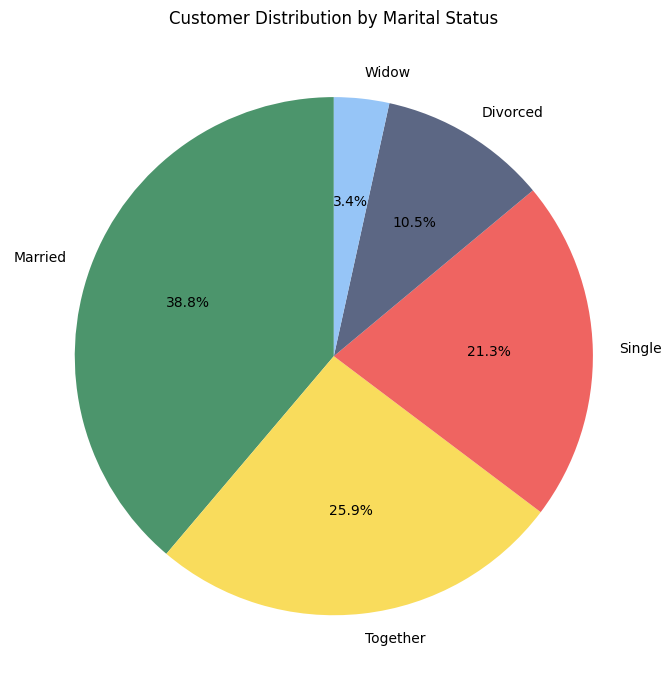

In [12]:
status_counts = df["Marital_Status"].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(status_counts, labels=status_counts.index, autopct="%1.1f%%", startangle=90,
        colors=["#4C956C", "#F9DC5C", "#EF6461", "#5C6784", "#96C5F7"])
plt.title("Customer Distribution by Marital Status")
plt.tight_layout()
plt.show()

**✅ Answer :-**
* Majority of the customers are **Married** or **Together**, together making up more than half of the total customer base.
* **Single** customers form the next biggest group, while **Divorced** and **Widow** customers are a smaller share.
* So, the answer to our question is — the core customer base is **people in relationships/families**, not singles.

**Interpretation :-**
* This makes sense for an FMCG company since household products and groceries are usually bought for the family.
* Marketing campaigns and family-pack offers could specifically target the Married/Together segment since they are the largest group.

---
### 🔵 Graph 3 — Income vs Total Spending (Scatter Plot)
---
**❓ Question we are trying to answer:**
*Does a customer's income actually affect how much they spend on FMCG products?*

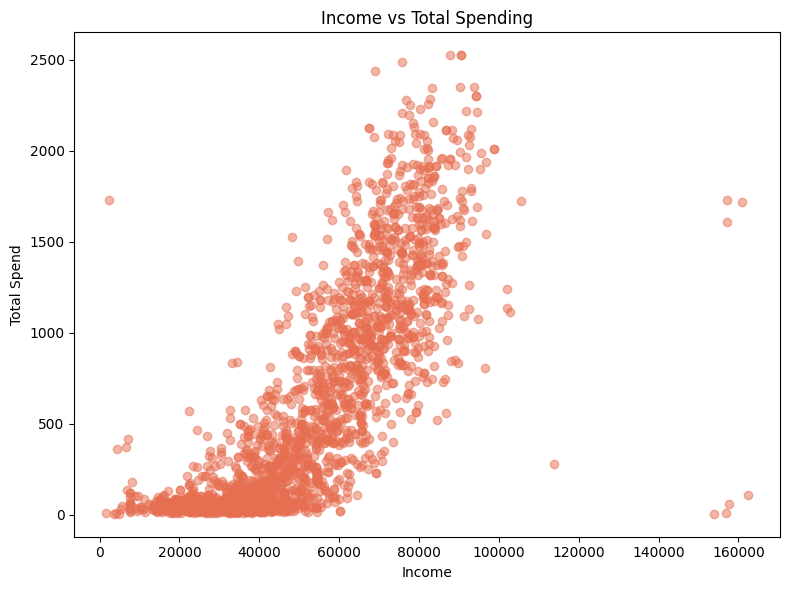

In [13]:
plt.figure(figsize=(8, 6))
plt.scatter(df["Income"], df["Total_Spend"], alpha=0.5, color="#E76F51")
plt.xlabel("Income")
plt.ylabel("Total Spend")
plt.title("Income vs Total Spending")
plt.tight_layout()
plt.show()

**✅ Answer :-**
* Yes — there is a clear **positive relationship** between Income and Total Spend — as income increases, total spending on products also increases.
* Most low-income customers (below ~30,000) spend very little, mostly under 200 in total.
* Higher income customers (above ~60,000) show a much wider spread and spend significantly more, some crossing 2000 in total spend.
* So, the answer to our question is — **yes, income strongly affects spending.**

**Interpretation :-**
* This confirms that income is one of the strongest factors affecting purchase behaviour for this FMCG company.
* Premium offers can be targeted at high income customers while budget-friendly combo packs can be targeted at lower income customers.

---
## Conclusion

* Wine and Meat products bring in the most revenue, so the company should focus on these categories.
* Married and Together customers form the largest customer base, making them the primary target segment.
* Income has a strong positive effect on total spending, so pricing and offers can be planned differently for different income groups.

**This concludes the FMCG Customer & Sales Analysis 👁️👄👁️**